%%html
<style type="text/css">
  span.ecb { background: yellow; }
</style>
<span class="ecb">1-3. Wrong formula for E outside slab, leading to much-too-large value -5</span>
<br/>
<span class="ecb">4-5. Total -6</span>
<br/>
<span class="ecb">Total 64/75</span>


In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# from IPython.display import display
import itertools

# ATMO 5331 - Homework #2
### Spring 2026, Due 26 Feb, 2026, before start of class.

When working these problems, you will need to code up equations for and make plots of various electrostatic quantities. Turn in a Jupyter notebook with your figures and which I can run to reproduce your results. Label your axes like a professional.

Please also enter your derivation into the notebook using $LaTeX$.

Do not copy-paste code; if you feel tempted, write a function that repeats operations that follow a certain template. Those functions can be in the notebook itself, or in an accompanying .py file that you import into the notebook.

Provide any needed discussion as commentary in the notebook in a Markdown cell.

### 1. E from a charged slab

In lecture we used Gauss's law to show that the electric field produced by a thin sheet of charge with surface charge density $\sigma_q$ is given by $E(z) = \sigma_q / 2\epsilon$.

Using a similar approach, derive an expression for the vertical profile of the electric field produced by an inifinitely wide slab of space charge with thickness $H$ whose bottom is at a height of $z_0$ and has charge density $\rho$.

<span class="ecb">(5)</span>.

For outside the slab:

$ z < z_0 $ or $ z > z_0 + H $

From Gauss's Law:

$\oint_{sfc} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA = q_{encl}/\epsilon$

And knowing:

$ \rho = q/V $

Using our cylinder/pillbox, we have two circles that the flux travels through (one at the top of the slab and one at the bottom). We sum the flux through both circles to get the total flux through the cylinder:

$\oint_{top} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{top} + \oint_{bot} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{bot} = q_{encl}/\epsilon$

Rearrage $\rho$ to obtain $q$ and substitute:

$ q = \rho ~ V$

$ q_{encl}/\epsilon = \rho ~ V_{encl} / \epsilon $

Using the definition of the volume of a cylinder with $h$ being the height of the cylinder:

$ V= A ~ \cdot ~ h $

$ \rho ~ V_{encl} / \epsilon ~ = ~(A ~ \cdot ~ h) / \epsilon $

So:

$\oint_{top} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{top} + \oint_{bot} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{bot} ~ = ~\rho (A ~ \cdot ~ h) / \epsilon $

Taking the integrals, our LHS simplifies to:

$ 2 ~ E(z) ~ A ~ = ~\rho(A ~ \cdot ~ h) / \epsilon $

We know h is the height of the entire cylinder, or $h = z_0+H$

Isolate $E(z)$ and substitute h:

$ \boxed{E(z) ~ = ~ \rho (z_0+H) / 2\epsilon} $

***

For inside the slab:
$\vec{E}_{top} = - \vec{E}_{bot}$ 

$\vec{\nabla} \cdot \vec{E} = \frac{q}{\epsilon}$
$\oint_{top} ~ \vec{E} ~ \cdot ~ \hat{n} ~ dA_{top} = \oint_{vol} ~ (\vec{\nabla} \cdot \vec{E}) dV = \frac{q}{\epsilon} \oint_{vol} dV$

Understanding that the volume integral on the LHS would simplify to:

$ \frac{\rho V}{\epsilon}$

And that:

$ V = A \cdot h$

We can solve the integral and substitute:

$E(z) A = \frac{\rho A h}{\epsilon}$

$E(z) = \frac{\rho h}{\epsilon}$

Where $h$ the height of the Gaussian pillbox from the center of the slab, or:

$ h = z - z_{center} $

So,

$\boxed{E(z) = \frac{\rho (z - z_{center})}{\epsilon}}$

### 2. Plotting E
Using the given equation and the one you derived in problem 1., complete the two functions below, as described by their documentation strings (docstrings).

<span class="ecb">(10)</span>.

In [2]:
epsilon = 8.854e-12 #F/m

def sheet_E(z, z_0, sigma_q):
    """
    Given a height z, return the electric field produced by an
    inifintely thin layer horizontal of charge located at height z_0, 
    with surface charge density sigma_q.
    
    Units:
    """
    # E based on whether you're above the sheet or below the sheet
    E = np.where(z > z_0,
             sigma_q / (2 * epsilon),
             -sigma_q / (2 * epsilon))

    return E

def slab_E(z, z_0, H, rho):
    """ 
    Given a height z, return the electric field produced by an 
    infinite horizontal slab of charge whose bottom is at z_0, top is at z_0+H
    and with constant volumetric charge density rho.
    
    Units:
    """

    # create BCs
    
    outside_top = (z >= z_0 + H)
    outside_bottom = (z <= z_0)
    #inside = ((z < z_0 + H) & (z > z_0))

    inside_top = ((z < z_0 + H) & (z > z_0 + (H/2)))
    inside_bot = ((z < z_0 + (H/2)) & (z > z_0))

    center = z_0 + (H/2)
    inside = ((z>=z_0) & (z<=z_0+H))

    # define our E fields
    
    outside_top_E = (rho *(z_0 + H)) / (2 * epsilon)
    outside_bot_E = -(rho * (z_0 + H)) / (2 * epsilon)
    inside_E = rho * (z-center) / epsilon
    # inside_top_E = (rho * z) / epsilon
    # inside_bot_E = -(rho * z) / epsilon

    #BCs = [outside_bottom, inside_bot, inside_top, outside_top]
    BCs = [outside_bottom, inside, outside_top]

    E_fields = [outside_bot_E, inside_E, outside_top_E]

    E = np.select(BCs, E_fields) # finds where BCs are true and sets the appropriate E field
                  

    return E

all_z = np.arange(0, 15e3, 100.0) # Use these altitudes when making plots.

### 3. Plots

Ignoring the effect of a conducting ground plane, 

**a.** Plot the electric field profile produced by an inifinitely thin layer of charge (in isolation) at a cloud top height of 8 km for a surface charge density of +.5 µC/m$^2$.

**b.** Plot the electric field profile produced by an inifinitely thin layer of charge (in isolation) at a cloud bottom height of 5 km for a surface charge density of +.5 µC/m$^2$.

**c.** Plot the electric field profile for a slab (in isolation) using a charge density of -1 nC/m$^3$, bottom height of 6 km, and thickness of 1 km.

**d.** Plot the sum of the electric fields calculated in a,b,c.

<span class="ecb">(5 each, 15 total)</span>.

In [3]:
import matplotlib
# matplotlib.use('WebAgg')
import matplotlib.pyplot as plt

red_blue = plt.get_cmap('RdBu_r')
helix = plt.get_cmap('cubehelix_r')

In [4]:
all_z

array([    0.,   100.,   200.,   300.,   400.,   500.,   600.,   700.,
         800.,   900.,  1000.,  1100.,  1200.,  1300.,  1400.,  1500.,
        1600.,  1700.,  1800.,  1900.,  2000.,  2100.,  2200.,  2300.,
        2400.,  2500.,  2600.,  2700.,  2800.,  2900.,  3000.,  3100.,
        3200.,  3300.,  3400.,  3500.,  3600.,  3700.,  3800.,  3900.,
        4000.,  4100.,  4200.,  4300.,  4400.,  4500.,  4600.,  4700.,
        4800.,  4900.,  5000.,  5100.,  5200.,  5300.,  5400.,  5500.,
        5600.,  5700.,  5800.,  5900.,  6000.,  6100.,  6200.,  6300.,
        6400.,  6500.,  6600.,  6700.,  6800.,  6900.,  7000.,  7100.,
        7200.,  7300.,  7400.,  7500.,  7600.,  7700.,  7800.,  7900.,
        8000.,  8100.,  8200.,  8300.,  8400.,  8500.,  8600.,  8700.,
        8800.,  8900.,  9000.,  9100.,  9200.,  9300.,  9400.,  9500.,
        9600.,  9700.,  9800.,  9900., 10000., 10100., 10200., 10300.,
       10400., 10500., 10600., 10700., 10800., 10900., 11000., 11100.,
      

In [5]:
all_x = np.arange(0, 5e3, 100.0)

In [6]:
all_x

array([   0.,  100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,
        900., 1000., 1100., 1200., 1300., 1400., 1500., 1600., 1700.,
       1800., 1900., 2000., 2100., 2200., 2300., 2400., 2500., 2600.,
       2700., 2800., 2900., 3000., 3100., 3200., 3300., 3400., 3500.,
       3600., 3700., 3800., 3900., 4000., 4100., 4200., 4300., 4400.,
       4500., 4600., 4700., 4800., 4900.])

In [7]:
z_0a = 8e3
sigma_a = 0.5e-6

z_0b = 5e3
sigma_b = 0.5e-6

z_0c = 6e3
rho_c = -1e-9
H_c = 1e3

E_a = sheet_E(all_z, z_0a, sigma_a)
E_2D_a = E_a[:, None] * np.ones_like(all_x) # make E_a into a 2D field so we can plot x and z

E_b = sheet_E(all_z, z_0b, sigma_b)
E_2D_b = E_b[:, None] * np.ones_like(all_x)

E_c = slab_E(all_z, z_0c, H_c, rho_c)
E_2D_c = E_c[:, None] * np.ones_like(all_x)

E_all = E_a + E_b + E_c
E_all_2D = E_2D_a + E_2D_b + E_2D_c

In [8]:
E_a.shape

(150,)

In [9]:
E_2D_a.shape

(150, 50)

In [10]:
def wind_barbs_uw(E):
    U = np.zeros_like(all_x) # no horizontal component
    W = E * 1e-4 # decrease magnitude so we can actually plot the barbs

    return U, W

In [11]:
U_a, W_a = wind_barbs_uw(E_a)
U_b, W_b = wind_barbs_uw(E_b)
U_c, W_c = wind_barbs_uw(E_c)
U_all, W_all = wind_barbs_uw(E_all)

In [12]:
def e_plot(ax, E_2D, cmap, skips, skipb, U, W):
    skipbig = 6
    skipsmall = 2
    #fieldnorm = matplotlib.colors.Normalize(vmin=min(E_a), vmax=max(E_a))
    
    plot = ax.pcolormesh(all_x, all_z, E_2D, cmap=cmap)
    ax.barbs(all_x[::skips], all_z[::skipb], U[::skips], W[::skipb], barbcolor=['r'])
    plt.colorbar(plot, label='E Field Magnitude (V/m)', ax=ax)
    ax.set_xlabel('Meters in X (m)')
    ax.set_ylabel('Meters in Z (m)')

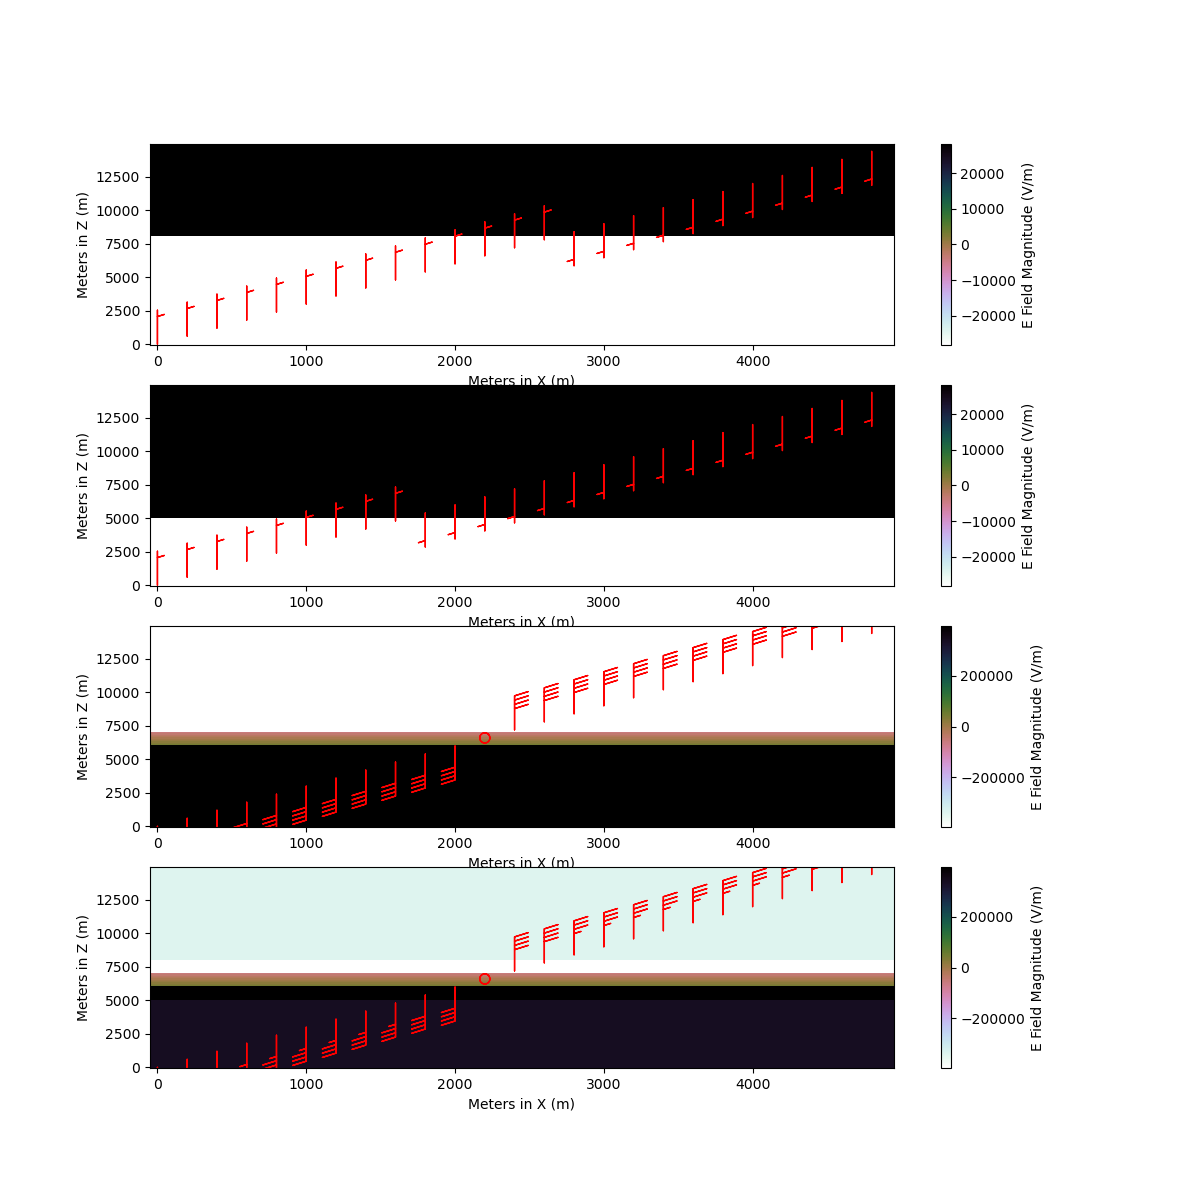

In [13]:
fig, axes = plt.subplots(4,1, figsize=(12,12))

ax_a = axes[0]
ax_b = axes[1]
ax_c = axes[2]
ax_d = axes[3]

skipbig = 6
skipsmall = 2

e_plot(ax_a, E_2D_a, helix, skipsmall, skipbig, U_a, W_a)
e_plot(ax_b, E_2D_b, helix, skipsmall, skipbig, U_b, W_b)
e_plot(ax_c, E_2D_c, helix, skipsmall, skipbig, U_c, W_c)
e_plot(ax_d, E_all_2D, helix, skipsmall, skipbig, U_all, W_all)
plt.show()

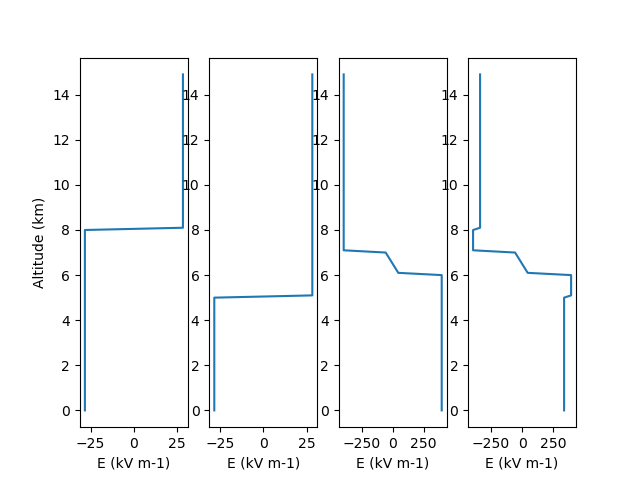

In [15]:
# ECB added this to check values of E_z

E_3a = sheet_E(all_z, 8000.0, 0.5e-6)
E_3b = sheet_E(all_z, 5000.0, 0.5e-6)
E_3c = slab_E(all_z, 6000.0, 1000.0, -1.0e-9)
E_3d = E_3a+E_3b+E_3c

fig, axs = plt.subplots(1,4)#, sharey=True, sharex=True)
for ax in axs:
    _ = ax.set_xlabel('E (kV m-1)')
_ = axs[0].set_ylabel('Altitude (km)')

_ = axs[0].plot(E_3a/1000.0, all_z/1000.0)
_ = axs[1].plot(E_3b/1000.0, all_z/1000.0)
_ = axs[2].plot(E_3c/1000.0, all_z/1000.0)
_ = axs[3].plot(E_3d/1000.0, all_z/1000.0)

### 4. Combining charge and the effect of conductivity

Taking into account the conductivity difference of the cloud $\sigma_{\mathrm{cld}}$ and the clear air $\sigma_{\mathrm{clr}}$, use MacGorman and Rust eq. 2.4 (below) to derive an expression for the top and bottom surface charge densities $(\sigma_{q top}, \sigma_{q bot}$) as a function of the electric field at the top and bottom of the cloud. Here, we let the field inside the cloud determine the necessary "screening" charge that develops to equalize the electric field inside and outside the cloud. Assume that the ratio $\alpha = \sigma_{\mathrm{clr}}/ \sigma_{\mathrm{cld}}$ of clear and cloudy air conductivities is constant with height.

$
\begin{eqnarray}
E_{clr}(z_{top}) = E(z_{top}) + \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

$
\begin{eqnarray}
E_{cld}(z_{top}) = E(z_{top}) - \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

$
\begin{eqnarray}
E_{cld}(z_{bot}) = E(z_{bot}) - \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

$
\begin{eqnarray}
E_{clr}(z_{bot}) = E(z_{bot}) - \frac{\sigma_{q top}}{2\epsilon} - \frac{\sigma_{q bot}}{2\epsilon}
\end{eqnarray}
$

<span class="ecb">(10)</span>.


***

Starting with the ratios of $\vec{E}$ and $\sigma$:

$ \vec{E}_{cld} / \vec{E}_{clr} = \sigma_{clr} / \sigma_{cld} = \alpha $

So

$ \vec{E}_{cld} = \vec{E}_{clr} ~ \alpha $

Starting with the top half of the system:

$ E(z_{top}) - \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon} = \alpha ~ (E(z_{top}) + \frac{\sigma_{q top}}{2\epsilon} + \frac{\sigma_{q bot}}{2\epsilon}) $

Isolate $\sigma$s by removing denominator:

$ 2\epsilon E(z_{top}) - \sigma_{q top} + \sigma_{q bot} = \alpha ~ (2\epsilon E(z_{top}) + \sigma_{q top} + \sigma_{q bot})$

Distribute $\alpha$ and combine like terms:

$ 2\epsilon E(z_{top}) - 2\epsilon E(z_{top})\alpha = \alpha\sigma_{q top} + \sigma_{q top} + \alpha\sigma_{q bot} - \sigma_{q bot} $ 

top: $ {2\epsilon E(z_{top}) (1 - \alpha) = \sigma_{q top} (\alpha + 1) + \sigma_{q bot} (\alpha -1)}$

Do the same for the bottom half (skipped for brevity):

$ 2\epsilon E(z_{bot}) (1 - \alpha) = \sigma_{q top} (1 - \alpha) + \sigma_{q bot} (\alpha + 1)$

Pull out a $-$ to make $(1 - \alpha) = -(\alpha -1) $ :

bot: $ \boxed{2\epsilon E(z_{bot}) (\alpha - 1) = \sigma_{q top} (\alpha -1) - \sigma_{q bot} (\alpha + 1)}$

top: $ \boxed{2\epsilon E(z_{top}) (\alpha - 1) = \sigma_{q top} (\alpha + 1) + \sigma_{q bot} (\alpha -1)}$

***

Now add bot and top equations via: $ x = x, ~y = y, ~x+y = x+y$

$ 2\epsilon E(z_{bot}) (\alpha - 1) + 2\epsilon E(z_{top}) (\alpha - 1) =  \sigma_{q top} (\alpha -1) - \sigma_{q bot} (\alpha + 1) + \sigma_{q top} (\alpha + 1) + \sigma_{q bot} (\alpha -1)$

$\sigma_{q top} [(\alpha +1) + (\alpha -1)] + \sigma_{q bot}[(\alpha -1) + (\alpha +1)] = 2\alpha \sigma_{q top} + 2\alpha \sigma_{q bot}$

$ 2\alpha \sigma_{q top} + 2\alpha \sigma_{q bot} = 2 {\epsilon (\alpha-1)} [E(z_{bot}) - E(z_{top})]$

$ (A): \boxed{\sigma_{q top} + \sigma_{q bot} = {\epsilon (\alpha-1)}{\alpha} [E(z_{bot}) - E(z_{top})]} $

And subtract bot and top equations:

$ \sigma_{q top}[(\alpha + 1) - (\alpha -1)] + \sigma_{q bot}[(\alpha -1) - (\alpha +1)] = 2\sigma_{q top} - 2\sigma_{q bot}$

$ 2\sigma_{q top} - 2\sigma_{q bot} = -2 \epsilon E(z_{top})(\alpha -1) -2\epsilon E(z_{bot})(\alpha -1)$


$ (B): \boxed{\sigma_{q top} - \sigma_{q bot} = -\epsilon (\alpha -1)[E(z_{top}) + E(z_{bot})]} $


***

Now add $(A)$ and $(B)$:, isolates $\sigma_{q top}$:

$ \sigma_{q top} + \sigma_{q bot} + \sigma_{q top} - \sigma_{q bot} = 2\sigma_{q top} $

$ 2\sigma_{q top} = \frac{\epsilon(\alpha -1)}{\alpha} [E(z_{bot}) - E(z_{top})] - \epsilon(\alpha -1) [E(z_{top}) + E(z_{bot})] $

Common denominator:

$ 2\sigma_{q top} = \frac{\epsilon(\alpha -1)}{\alpha} [E(z_{bot}) - E(z_{top}) - \alpha E(z_{top}) - \alpha E(z_{bot})]$

Regroup:

$ 2\sigma_{q top} = \frac{\epsilon(\alpha -1)}{\alpha} [E(z_{bot})(1 - \alpha) - E(z_{top})(1 + \alpha)]$

Factor out a $-$ and divide by 2:

$ \boxed{\sigma_{q top} = -\frac{\epsilon(\alpha -1)}{2\alpha} [E(z_{bot})(\alpha-1) + E(z_{top})(1 + \alpha)]}$

Subtracting $(A)$ and $(B)$, isolates $\sigma_{q bot}$:

$ \boxed{\sigma_{q bot} = \frac{\epsilon(\alpha -1)}{2\alpha} [E(z_{bot})(1+\alpha) + E(z_{top})(\alpha-1)]}$

<span class="ecb">In the step where you add (A) and (B), it should be multiplication and not division by alpha before you find the common denominator. This leads to some other errors; there should second order polynomial terms in the final expression for each charge density. -3</span>

### 5. Plot the combined cloud 

Assuming a cloud base of $z=5$ km and a cloud top of $z=8$ km, the slab of charge from problem **3c.**, and the formula you derived for **4.**, plot the electric field profile produced by the combined effect of the slab of charge and the effect of the screening charge at the cloud boundary. Let $\alpha = 10$. Again ignore the effect of a conducting ground plane.

<span class="ecb">(10 pts.)</span>.

The E field outside the cloud is the same as the E-field produced by the slab at those altitudes as the E-field is constant outside the slab. The Efield outside the cloud does not need to be calculated then, only inside the cloud.

<span class="ecb">Still need to include slab E here - it is the thing that drives the conduction currents to make the screening layer. -3</span>

In [15]:
def E_with_cld(z, z_cld_bot, z_cld_top, alpha, E_other):

    # Define BCs
    cld_middle = (z_cld_bot + z_cld_top) / 2

    outside_top = (z>=z_cld_top)
    outside_bot = (z<=z_cld_bot)

    inside_bot = ((z<=cld_middle) & (z>z_cld_bot))
    inside_top = ((z>=cld_middle) & (z<z_cld_top))


    # Find E fields
    outside_top_E = E_other[z==z_cld_top]
    outside_bot_E = E_other[z==z_cld_bot]

    b = epsilon * (alpha -1)/(2*alpha)
    sigma_qtop = -b * (outside_bot_E * (alpha -1)) + (outside_top_E * (1 + alpha))
    sigma_qbot = b * (outside_bot_E * (1+ alpha)) + (outside_top_E * (alpha-1))
    
    E_cld_top = sheet_E(z, z_cld_top, sigma_qtop)
    E_cld_bot = sheet_E(z, z_cld_bot, sigma_qbot)


    #BCs = [outside_bot, outside_top, inside_bot, inside_top]

    BCs = [inside_bot, inside_top]

    #E_fields = [outside_bot_E, outside_top_E, E_cld_bot, E_cld_top]

    E_fields = [E_cld_bot, E_cld_top]

    E = np.select(BCs, E_fields) # finds where BCs are true and sets the appropriate E field

    return E

In [16]:
z_cld_bot = 5e3
z_cld_top = 8e3
alpha=10
E_cld = E_with_cld(all_z, z_cld_bot, z_cld_top, alpha, E_c)

In [17]:
E_all = E_cld + E_c

In [18]:
E_all

array([ 3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05,  3.95301559e+05,
        3.95301559e+05,  3.95301559e+05,  3.95301559e+05, -2.00909986e+17,
       -2.00909986e+17, -

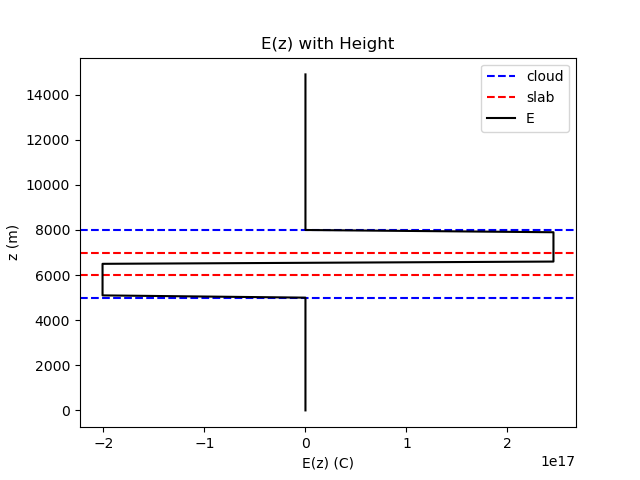

In [19]:
fig = plt.figure()
plt.axhline(y=8e3, linestyle='--', color='blue', label='cloud')
plt.axhline(y=5e3, linestyle='--', color='blue')
plt.axhline(y=6e3, linestyle='--', color='red')
plt.axhline(y=7e3, linestyle='--', color='red', label='slab')
plt.plot(E_all, all_z, color='black', label='E')
plt.legend()
plt.xlabel('E(z) (C)')
plt.ylabel('z (m)')
plt.title('E(z) with Height')
plt.show()

### 6. Point charges

Let's now consider finite charge regions, beginning with simple point charges. Write another function, `point_E(r, r_0, q)` that mimics the function call signature of your sheet and slab, changing the arguments to reflect the parameters relevant to a point charge. Here, `r` is an array of `(x, y, z)` locations at which to calculate the electric field, and `r_0` is the `(x_0,y_0,z_0)` location of the charge given by `q`.

<span class="ecb">(10 pts.)</span>.

In [20]:
from numpy import linalg
def point_E(r, r_0, q):
    """
    Returns the electric field at (x,y,z) = r.
    produced by a point charge q at (x0, y0, z0) = r0.
    
    Units:
    """
    r_vector = r-r_0
    print(f'r_vector shape: {r_vector.shape}')
    r_norm = np.linalg.norm(r_vector, axis=-1)
    r_norm[r_norm==0] = np.nan # so i dont divide by 0
    r_norm = r_norm[..., np.newaxis]
    print(f'r_norm shape: {r_norm.shape}')
    
    # Replace this line with your own E.
    E = (1/(4 * np.pi * epsilon)) * (q/(r_norm**2)) * (r_vector/r_norm)
    
    return E

### 7. Plotting a stack of point charges

Assume a thunderstorm is represented by **four point charges** located at x=0, y=0 in a vertical stack, **above a conducting ground plane**. Using the function you wrote in **6.**, calculate the electric field produced by the sum of all charges and plot the elecric field vectors in the X, Z plane. 

For the point charges, use altitudes of 4, 7, 10, and 12 km, centered at x=0, and charges of +15 C, -45 C, +40 C, -20 C, to match the electric configuration in [Krehbiel et al.](http://dx.doi.org/10.1038/ngeo162) (2008, Nature Geosci., Fig. 4c, low altitude -IC).

Make 3 plots:
1. The electric field in the $x, z$ plane at +/- 10 km range from the center of the stack, and from 0 to 16 km altitude.
2. The vertical profile of the electric field from -16 to 16 km.
3. The Ex, Ey, and Ez field components with range along the ground (x coordinate), using matplotlib's `fill_between` to highlight negative values of $E_z$.

<span class="ecb">(15 pts.)</span>

In [21]:
x = np.arange(-10e3, 10e3, .2e3, dtype=float)
z = np.arange(-16e3, 16e3, .2e3, dtype=float)    
X, Z = np.meshgrid(x,z)
Y = np.zeros_like(X)

In [22]:
z_0 = np.array([4e3, 7e3, 10e3, 12e3])
r_0 = np.stack((np.zeros_like(z_0), np.zeros_like(z_0), z_0), axis=-1) # x, y, z for every point charge, stack joins the arrays so that they can be in x,y, z order

# X_short = X[z>=0]
# Y_short = Y[z>=0]
# Z_short = Z[z>=0]
print(f'r_0 shape:{r_0.shape}') # 4 charges in 3 dimensions
# make r also in x, z
r = np.stack((X, Y, Z), axis=-1) # (x,y,z) pairs
print(f'r shape: {r.shape}')

r_reshape = r[..., np.newaxis, :] # we need to make an extra dimension since we don't have one for r0 = 4 yet, but we need to keep 2 at the end so we can subtract
print(f'r_reshape: {(r_reshape).shape}')
r_0_reshape = r_0[np.newaxis, np.newaxis, :, :] # this makes r_0 the "same" shape as r since r has the extra 2 dimensions at the beginning
print(f'r_0 reshape: {(r_0_reshape).shape}')

r_vector = r_0_reshape - r_reshape
print(f'r_vector shape: {r_vector.shape}')

q_array = np.array([15, -45, 40, -20])
q = q_array[np.newaxis, np.newaxis, :, np.newaxis] # makes q also in same dimensions
print(f'q shape:{q.shape}')

r_0 shape:(4, 3)
r shape: (160, 100, 3)
r_reshape: (160, 100, 1, 3)
r_0 reshape: (1, 1, 4, 3)
r_vector shape: (160, 100, 4, 3)
q shape:(1, 1, 4, 1)


In [23]:
E_all = point_E(r_reshape, r_0_reshape, q)
E_all_opposite = point_E(r_reshape, -r_0_reshape, -q) # create equal and opposite charges to make conducting ground plane, r does not change
E_total = np.sum(E_all, axis=2)# (Nz, Nx, 2)
E_total_opposite = np.sum(E_all_opposite, axis=2)
E_total_conduct = E_total + E_total_opposite

r_vector shape: (160, 100, 4, 3)
r_norm shape: (160, 100, 4, 1)
r_vector shape: (160, 100, 4, 3)
r_norm shape: (160, 100, 4, 1)


In [24]:
E_total.shape

(160, 100, 3)

In [25]:
E_total_conduct.shape

(160, 100, 3)

In [26]:
# create x, y, z components to plot vectors
Ex = E_total_conduct[..., 0]
Ey = E_total_conduct[..., 1]
Ez = E_total_conduct[..., 2]

In [27]:
z_positive = z>=0

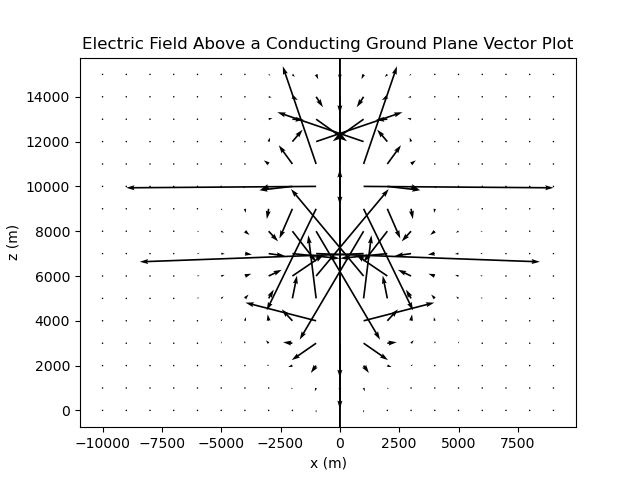

In [28]:
skip = 5 # how frequently to skip to plot vectors neatly

plt.figure()

plt.quiver(
    X[z_positive, :][::skip, ::skip],
    Z[z_positive, :][::skip, ::skip],
    Ex[z_positive, :][::skip, ::skip],
    Ez[z_positive, :][::skip, ::skip]
)

plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.title('Electric Field Above a Conducting Ground Plane Vector Plot')
plt.show()

In [29]:
Ez.shape

(160, 100)

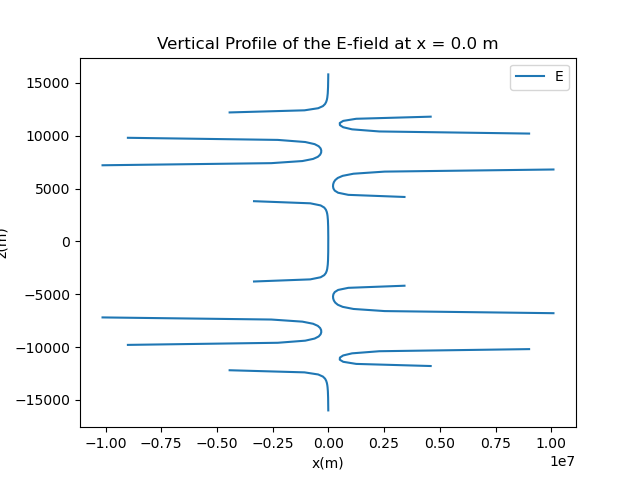

In [30]:
x_index = Ez.shape[1] // 2 # floor division, rounds down to nearest whole number and guarantees a float
plt.figure()
plt.plot(Ez[:, x_index], z, label='E')
plt.title(f'Vertical Profile of the E-field at x = {x[x_index]} m')
plt.ylabel('z(m)')
plt.xlabel('x(m)')
plt.legend()
plt.show()

In [31]:
z_index = Ez.shape[0] // 2 # the center of z, aka z = 0, which is the ground plane

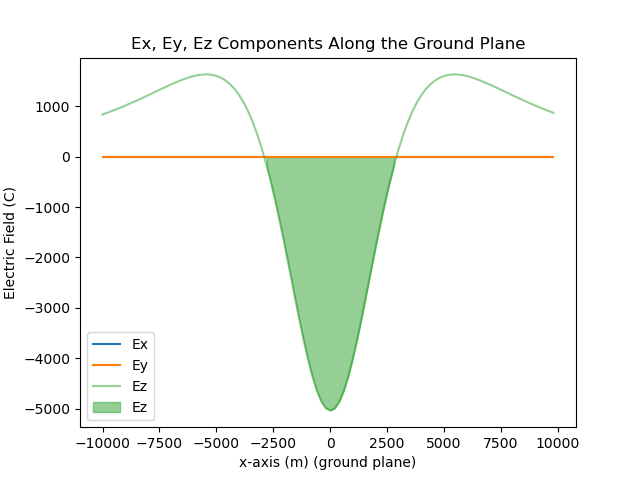

In [32]:
plt.figure()
plt.plot(X[z_index,:], Ex[z_index,:], label='Ex')
plt.plot(X[z_index,:], Ey[z_index,:], label='Ey')
plt.plot(X[z_index,:], Ez[z_index,:], label='Ez', alpha=0.5)
plt.fill_between(X[z_index,:], Ez[z_index,:], 0, where=(Ez[z_index,:] < 0), label='Ez', alpha=0.5, color='tab:green')
plt.xlabel('x-axis (m) (ground plane)')
plt.ylabel('Electric Field (C)')
plt.title('Ex, Ey, Ez Components Along the Ground Plane')
plt.legend()
plt.show()

## Widgets

In [ ]:
class ChargeStack(object):
    """ Widget contoller for a stack of finite charge regions centered at some 
    altitude and parameterized by a depth and radius parameter."""
    
    def __init__(self, postprocess=None, n_charges=1):
        self.postprocess=postprocess
        self.update_plot = True
        
        alt_defaults = dict(    
            value=7.5,
            min=0,
            max=15.0,
            step=0.1,
            description='z',
            disabled=False,
            continuous_update=False,
            orientation='vertical',
            readout=True,
            readout_format='.1f',
        )

        q_defaults = alt_defaults.copy()
        q_defaults['max']=100
        q_defaults['min']=-q_defaults['max']
        q_defaults['step']=1
        q_defaults['value']=0
        q_defaults['description']='q'
        
        r_defaults = alt_defaults.copy()
        r_defaults['max']=10
        r_defaults['step']=.5
        r_defaults['value']=5
        r_defaults['description']='R'

        h_defaults = alt_defaults.copy()
        h_defaults['max']=5
        h_defaults['step']=.1
        h_defaults['value']=1
        h_defaults['description']='H'

        z_sliders = [widgets.FloatSlider(**alt_defaults) for i in range(n_charges)]
        q_sliders = [widgets.FloatSlider(**q_defaults) for i in range(n_charges)]
        r_sliders = [widgets.FloatSlider(**r_defaults) for i in range(n_charges)]
        h_sliders = [widgets.FloatSlider(**h_defaults) for i in range(n_charges)]
        
        all_sliders = (z_sliders, q_sliders, r_sliders, h_sliders)

        solid_border = widgets.Layout(border='solid 1px #dddddd', margin='3px')
        full_width = widgets.Layout(width='100%')

        # Create a list of paired z/q sliders with a label above them
        charge_widgets = [widgets.VBox([widgets.Label('Charge region {0}'.format(i), layout=full_width),
                                        widgets.HBox([*param_bundle], layout=solid_border)])
                          for i, param_bundle in enumerate(zip(*all_sliders))]
        # Lay out all the widgets for each charge in a single row
        self.widgets = widgets.HBox(charge_widgets)
        
        # Any time a widget changes, recalculate everything
        for w in itertools.chain(*all_sliders):
            w.observe(self._recalculate, names='value')
        
        self.n_charges = n_charges
        self.z_sliders = z_sliders
        self.q_sliders = q_sliders
        self.r_sliders = r_sliders
        self.h_sliders = h_sliders
        self.charge_widgets = charge_widgets
        
    def _recalculate(self, changed):
        q = np.fromiter((w.value for w in self.q_sliders), dtype=float)
        z = np.fromiter((w.value for w in self.z_sliders), dtype=float)
        R = np.fromiter((w.value for w in self.r_sliders), dtype=float)*1.0e3
        H = np.fromiter((w.value for w in self.h_sliders), dtype=float)*1.0e3

        r0 = np.zeros((z.shape[0], 3),dtype=float)
        r0[:,2] = z*1.0e3
        if self.postprocess:
            if self.update_plot:
                self.postprocess(r0, q, R, H)
            
def direct_set_widgets(charge_stack, vals):
    stack_widgets = charge_stack.z_sliders, charge_stack.h_sliders, charge_stack.r_sliders, charge_stack.q_sliders

    # Save some time by just not plotting until all the widgets have been changed
    charge_stack.update_plot = False
    for param_and_widget in zip(vals, stack_widgets):
        for vi, wi in zip(*param_and_widget):
            wi.value=vi
    charge_stack.update_plot = True
    charge_stack._recalculate(True)

In [ ]:
# Close the widget with the "x" and rerun this cell if the interface doesn't work.
plot_E = plt.figure()
charge_stack = ChargeStack(postprocess=plot_E, n_charges=4)
display(charge_stack.widgets) # display the widget

In [ ]:
# Set the values of the sliders to those given by MacGorman and Rust (1998), Fig. 3.1

MR31_z = 8, 5, 6, 6
MR31_h = 1.5, 1.5, 1.5, 1.5
MR31_r = 4, 4, 4, 4
MR31_q = 40, -40, 0, 0

MR31_vals = (MR31_z, MR31_h, MR31_r, MR31_q)

direct_set_widgets(charge_stack, MR31_vals)